## Convolutional Networks

We'll check out how to build a **convolutional network** to classify CIFAR10 images. By using weight sharing - multiple units with the same weights - convolutional layers are able to learn repeated patterns in your data. For example, a unit could learn the pattern for an eye, or a face, or lower level features like edges.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import numpy as np
import time

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
import torch.utils.data as utils
from torchvision import datasets, transforms
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.datasets import CIFAR10

%matplotlib inline

In [3]:
label_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


def plot_images(images, cls_true, cls_pred=None):
    """
    Adapted from https://github.com/Hvass-Labs/TensorFlow-Tutorials/
    """
    fig, axes = plt.subplots(3, 3)

    for i, ax in enumerate(axes.flat):
        # plot img
        ax.imshow(images[i, :, :, :], interpolation='spline16')

        # show true & predicted classes
        cls_true_name = label_names[cls_true[i]]
        if cls_pred is None:
            xlabel = "{0} ({1})".format(cls_true_name, cls_true[i])
        else:
            cls_pred_name = label_names[cls_pred[i]]
            xlabel = "True: {0}\nPred: {1}".format(
                cls_true_name, cls_pred_name
            )
        ax.set_xlabel(xlabel)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

In [ ]:
def get_train_valid_loader(data_dir='data',
                           batch_size=64,
                           augment=False,
                           random_seed=1,
                           valid_size=0.02,
                           shuffle=True,
                           show_sample=True,
                           num_workers=4,
                           pin_memory=False):
    """
    Utility function for loading and returning train and valid
    multi-process iterators over the CIFAR-10 dataset. A sample
    9x9 grid of the images can be optionally displayed.
    If using CUDA, num_workers should be set to 1 and pin_memory to True.
    Params
    ------
    - data_dir: path directory to the dataset.
    - batch_size: how many samples per batch to load.
    - augment: whether to apply the data augmentation scheme
      mentioned in the paper. Only applied on the train split.
    - random_seed: fix seed for reproducibility.
    - valid_size: percentage split of the training set used for
      the validation set. Should be a float in the range [0, 1].
    - shuffle: whether to shuffle the train/validation indices.
    - show_sample: plot 9x9 sample grid of the dataset.
    - num_workers: number of subprocesses to use when loading the dataset.
    - pin_memory: whether to copy tensors into CUDA pinned memory. Set it to
      True if using GPU.
    Returns
    -------
    - train_loader: training set iterator.
    - valid_loader: validation set iterator.
    """
    error_msg = "[!] valid_size should be in the range [0, 1]."
    assert ((valid_size >= 0) and (valid_size <= 1)), error_msg

    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )

    # define transforms for validation (no augmentation)
    valid_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    # Define the transform for training (and data augmentation)

    train_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    # load the dataset
    train_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=train_transform,
    )

    valid_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=valid_transform,
    )

    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, sampler=train_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset, batch_size=batch_size, sampler=valid_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )

    # visualize some images if requested
    if show_sample:
        sample_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=9, shuffle=shuffle,
            num_workers=num_workers, pin_memory=pin_memory,
        )
        data_iter = iter(sample_loader)
        images, labels = next(data_iter)
        # Unnormalize the images for display
        mean = [0.4914, 0.4822, 0.4465]
        std = [0.2023, 0.1994, 0.2010]
        unnorm_images = [unnormalize(img, mean, std) for img in images]
        X = torch.stack(unnorm_images).numpy().transpose([0, 2, 3, 1])
        plot_images(X, labels)

    return (train_loader, valid_loader)

def unnormalize(img, mean, std):
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    return img

trainloader, valloader = get_train_valid_loader()

# Convolutional Neural Network Architecture

Let's first talk about the overall architecture of a CNN and how each dimension evolves after each layer, we'll take as example the first and famous CNN LeNet5 :
<figure align="center">
  <img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/10/image-17.png" alt="LeNet5 Architecture" width="600">
  <figcaption>Image credit: <a href="https://en.wikipedia.org">Wikipedia</a></figcaption>
</figure>

For that, we will have some quick questions to see if you understand what happens during training/inference:

### 1. First Layer Convolution

If we consider the input of LeNet5 to be CIFAR-10, what would be the shape of the parameters of the first convolutional layer (stride = 1)?

- **A.** `torch.Size([6, 1, 5, 5])`
- **B.** `torch.Size([6, 3, 3, 3])`
- **C.** `torch.Size([6, 1, 5, 5])`
- **D.** `torch.Size([6, 3, 5, 5])`

### Answer 1

**Answer: D — `torch.Size([6, 3, 5, 5])`**

In PyTorch, the weight tensor of a `nn.Conv2d` layer always has the structure `torch.Size([out_channels, in_channels, kernel_H, kernel_W])`.

The first value is **6**, which is the number of output filters, a hyperparameter intrinsic to LeNet5's architecture.

The second value is **3**, corresponding to the number of input channels, CIFAR-10 images are RGB (3 channels), unlike the original LeNet5 which operated on grayscale MNIST images (1 channel). 

The last two values are both **5**, representing the height and width of each convolutional kernel, since LeNet5 uses 5×5 filters.

---

### 2. Subsampling Window

What is the shape of the subsampling window (stride = 2) for the second layer (between C1 and C2), and does this shape remain invariant regardless of the subsampling method (e.g., Avg pooling or Max pooling)?

- **A.** `2x2, yes it does`
- **B.** `3x3, no it doesn't`
- **C.** `2x2, no it doesn't`
- **D.** `yes, it does`

### Answer 2

**Answer: A — `2×2, yes it does`**

The output shape of layer S2 is `6×14×14`. This is obtained by applying a **2×2 pooling window** with stride 2 to the output of C1, which has shape `6×28×28`:

$$\text{output size} = \left\lfloor \frac{28 - 2}{2} \right\rfloor + 1 = 14$$

A 3×3 window with stride 2 would instead yield an output of size $\lfloor(28-3)/2\rfloor + 1 = 13$, which does not match the LeNet5 architecture. The kernel must therefore be 2×2.

Regarding the invariance, the shape of the subsampling window (`2×2`) is a **structural hyperparameter** of the layer. It defines which spatial region is aggregated, not how. Whether we use **Max Pooling** (taking the maximum value in the window) or **Average Pooling** (taking the mean), both operate over the exact same `2×2` window — only the output values of the two methods differ. The window shape therefore remains **invariant** regardless of the pooling method chosen.

---


### 3. Backpropagation for Convolutional Filters

Do the filters in the convolutional layers also benefit from backpropagation?



### Answer 3

Yes, the filters in the convolutional layers also benefit from backpropagation.
During training, the filters are treated as learnable parameters of the network. When the loss is computed, backpropagation calculates the gradient of the loss with respect to each filter weight.

These gradients indicate how each weight in the filter should be adjusted to reduce the error. Using an optimization algorithm such as stochastic gradient descent (SGD), the filter weights are then updated.

As a result, the convolutional filters progressively learn to detect useful features in the input images, such as edges, textures, or more complex patterns. In the case of CIFAR-10 classification with a LeNet-5-like architecture, the early convolutional layers typically learn low-level visual features, while deeper layers combine them into higher-level representations useful for classification.

---


### 4. Role of the Fully-Connected Layer

Explain in your own words why it is necessary to have a fully-connected layer in the architecture.

### Answer 4  TO CHECK
The fully-connected layer combines the features extracted by the convolutional layers and maps them to the output classes. After the feature maps are flattened, this layer learns how to use these features to perform the final classification.

---

If you had any struggle to answer one of theses questions, feel free to ask a TA about intuition or hints about the solution.

# Build your own Convolutional Neural Network Architecture

## Different ways to improve the accuracy of your network :
- Change the number of convolutions and layers (you can take inspiration from internet as you as you cite the architecture)
- Change the optmizer / its hyperparameters
- Add new types of layers
- Do some data augmentation in the get_train_valid_loader function (flipped, cropped, uncentered images) cf. https://pytorch.org/vision/stable/transforms.html


In [ ]:
class ConvNet(nn.Module):
    def __init__(self, n_input_channels=3, n_output=10):
        super().__init__()
        ################################################################################
        # TODO:                                                                        #
        # Define 2 or more different layers of the neural network                      #
        ################################################################################
        self.conv1 = nn.Conv2d(n_input_channels, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, n_output)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO:                                                                        #
        # Set up the forward pass that the input data will go through.                 #
        # A good activation function betweent the layers is a ReLu function.           #
        #                                                                              #
        # Note that the output of the last convolution layer should be flattened       #
        # before being inputted to the fully connected layer. We can flatten           #
        # Tensor `x` with `x.view`.                                                    #
        ################################################################################
        
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        return x

    def predict(self, x):
        logits = self.forward(x)
        return F.softmax(logits)

In [ ]:
net = ConvNet()
################################################################################
# TODO:                                                                        #
# Choose an Optimizer that will be used to minimize the loss function.         #
# Choose a critera that measures the loss                                      #
################################################################################
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

epochs = 15
steps = 0
running_loss = 0
print_every = 20
for e in range(epochs):
    start = time.time()
    for images, labels in iter(trainloader):

        steps += 1
        ################################################################################
        # TODO:                                                                        #
        # Run the training process                                                     #
        #                                                                              #
        #                                                                              #
        ################################################################################
        #History dictionary to store the training and validation accuracy and loss for each epoch
        if steps == 1:
            history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
            _train_correct_sum = [0]
            _train_total_sum = [0]
            _running_val_loss_acc = [0.0]
            
        optimizer.zero_grad()
        output = net.forward(images)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        loss = criterion(output, labels)
        ################################################################################
        # TODO:                                                                        #
        # Run the training process                                                     #
        #                                                                              #
        # HINT: Calculate the gradient and move one step further                       #
        ################################################################################
        loss.backward()
        optimizer.step()
        
        _, _pred_train = torch.max(output.data, 1)
        _train_correct_sum[0] += (_pred_train == labels).sum().item()
        _train_total_sum[0] += labels.size(0)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        running_loss += loss.item()

        if steps % print_every == 0:
            stop = time.time()
            # Test accuracy
            accuracy = 0
            for ii, (images, labels) in enumerate(valloader):

                ################################################################################
                # TODO:                                                                        #
                # Calculate the accuracy                                                       #
                ################################################################################
                with torch.no_grad():
                    output = net.forward(images)                                    # Get the output from the network for the validation images
                    val_loss_item = criterion(output, labels).item()                # Calculate the validation loss for this batch
                    _, predicted = torch.max(output.data, 1)                        # Get the predicted class with the highest score
                    accuracy += (predicted == labels).sum().item() / labels.size(0) # Update the running validation loss and accuracy
                    _running_val_loss_acc[0] += val_loss_item
                
                if ii == len(valloader) - 1:                                                           # If this is the last batch of the validation set,  
                    history['val_accuracy'].append(accuracy / (ii + 1))                                # calculate and store the average validation loss and accuracy for this epoch,
                    history['val_loss'].append(_running_val_loss_acc[0] / len(valloader))              # as well as the training loss and accuracy
                    history['accuracy'].append(_train_correct_sum[0] / max(_train_total_sum[0], 1))
                    history['loss'].append(running_loss / print_every)
                    _running_val_loss_acc[0] = 0.0
                    _train_correct_sum[0] = 0
                    _train_total_sum[0] = 0
                    
                ################################################################################
                #                              END OF YOUR CODE                                #
                ################################################################################

            print("Epoch: {}/{}..".format(e+1, epochs),
                  "Loss: {:.4f}..".format(running_loss/print_every),
                  "Test accuracy: {:.4f}..".format(accuracy/(ii+1)),
                  "{:.4f} s/batch".format((stop - start)/print_every)
                 )
            running_loss = 0
            start = time.time()


### Results (Bonus section for plot)

To monitor potential overfitting, the following plots display the training accuracy and validation accuracy on the same graph, along with the corresponding training and validation loss curves. If the training accuracy keeps increasing while the validation accuracy stagnates or decreases, it might be a begin of overfitting.

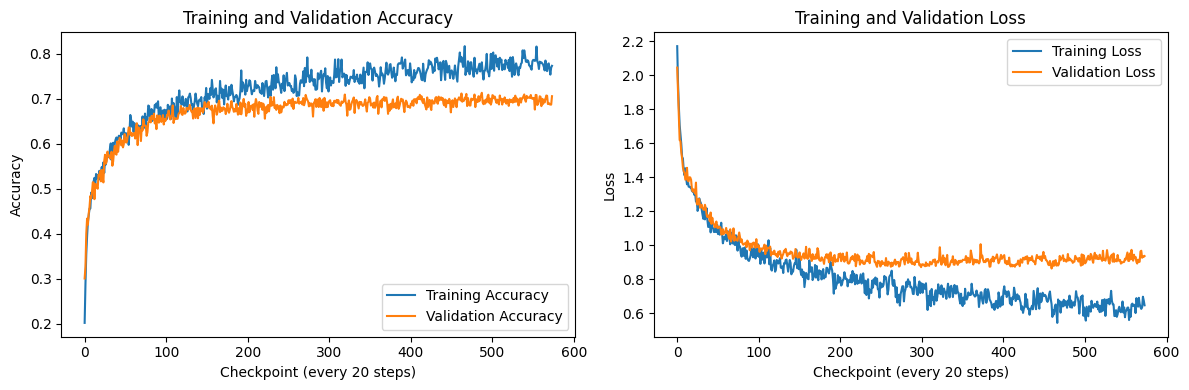

In [13]:
epochs_range = range(len(history['accuracy']))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Checkpoint (every 20 steps)')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['loss'], label='Training Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Checkpoint (every 20 steps)')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

Save best trained model.

In [19]:
## You should be familiar with how to save a pytorch model (Make sure to save the model in your Drive)
torch.save(net.state_dict(), 'drive/MyDrive/Colab Notebooks/CNN_15epochs.ckpt')

# Some visualisations and Interpretation questions
This code allows us to look at the filters of the first layer of convolution :

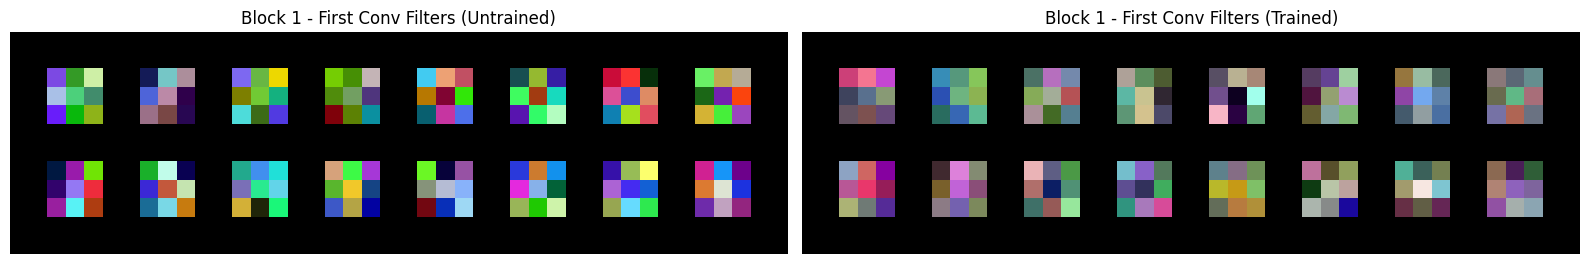

In [20]:
def visualize_filters(layer, title='Filters'):
    filters = layer.weight.data.clone().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min())
    grid = vutils.make_grid(filters, nrow=8, padding=2)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

model = ConvNet() # Untrained model

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Untrained filters ---
# "features[0]" is your first convolutionnal layer, you might have to change it to conv1 if it was the name you gave it to
filters_untrained = model.conv1.weight.data.clone().cpu()
filters_untrained = (filters_untrained - filters_untrained.min()) / (filters_untrained.max() - filters_untrained.min())
grid_untrained = vutils.make_grid(filters_untrained, nrow=8, padding=2)
axes[0].imshow(grid_untrained.permute(1, 2, 0))
axes[0].set_title("Block 1 - First Conv Filters (Untrained)")
axes[0].axis("off")

# --- Trained filters ---
filters_trained = net.conv1.weight.data.clone().cpu()
filters_trained = (filters_trained - filters_trained.min()) / (filters_trained.max() - filters_trained.min())
grid_trained = vutils.make_grid(filters_trained, nrow=8, padding=2)
axes[1].imshow(grid_trained.permute(1, 2, 0))
axes[1].set_title("Block 1 - First Conv Filters (Trained)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


#### What do you notice about the filters after the training ? Try to find an interpretation about it.


**Untrained filters** show completely random color patterns with no discernible structure. Each re-initialization of the network produces different random values, confirming that no learning has occurred yet.

**Trained filters** exhibit clear structured patterns. Three types of detectors can be identified:
- **Color channel detectors**: some filters respond predominantly to a single color (red, green, or blue), indicating they have specialized in detecting specific hues in the input image.
- **Directional edge detectors**: filters with smooth color gradients (e.g., red to blue, light to dark) detect intensity transitions in a given direction, capturing edges or contours.
- **Diversity across filters**: all 32 filters are visually distinct from one another, which is the expected outcome — backpropagation pushes each filter to specialize in a different type of feature to maximize the information extracted collectively.

**Note on filter count**
Two experiments were conducted, one with 16 filters and another with 32. The structured patterns described above were significantly harder to identify with only 16 filters, which motivated the switch to 32. With 32 filters, the specialization of each filter is visually much clearer. In terms of validation accuracy, the 32-filter model performed slightly better, although the improvement was marginal relative to the added computational cost. 

See [annexes](#Annexes) for the results of the simulation with 32 filters. 


### Activation maps
This code snippet uses a forward hook to capture the output of the first convolutional layer of a CNN when a sample image is passed through it. The resulting activation maps show how each filter in the layer responds to different regions or features in the image.

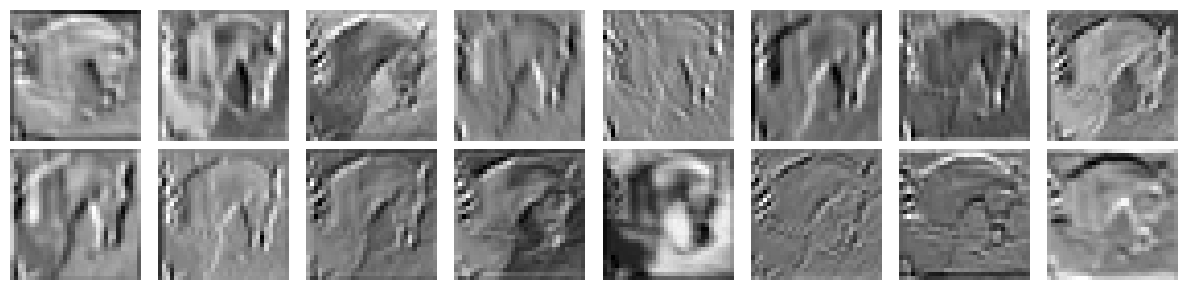

In [18]:
def get_activation(model, layer, x):
    activation = {}
    def hook_fn(module, input, output):
        activation['output'] = output.detach().cpu()
    hook = layer.register_forward_hook(hook_fn)
    model(x)
    hook.remove()
    return activation['output']

data_iter = iter(trainloader)
sample_images, sample_labels = next(data_iter)
sample_img = sample_images[1].unsqueeze(0)

# Get the feature maps after the first convolution (for example)
activation = get_activation(net, net.conv1, sample_img)

# Visualize a few feature maps in RGB:
def plot_feature_maps(feature_maps, n_cols=8):
    n_features = feature_maps.shape[1]
    n_rows = (n_features + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
    for i in range(n_features):
        plt.subplot(n_rows, n_cols, i + 1)
        # Extract the i-th feature map from the first (and only) sample in the batch
        act = feature_maps[0, i, :, :]
        # Normalize the activation map to [0, 1]
        act_norm = (act - act.min()) / (act.max() - act.min() + 1e-8)
        # Repeat the single channel 3 times to form an RGB image
        act_rgb = act_norm.unsqueeze(0).repeat(3, 1, 1)
        plt.imshow(act_rgb.permute(1, 2, 0))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_feature_maps(activation, n_cols=8)

# Play with the index of the chosen sample to notice more patterns and answer the question


### 1. Feature Detection
What specific features do you observe in these activation maps? Do some maps clearly highlight edges, contours, or textures? How might these features relate to the overall structure of the sample (e.g., the outline of a horse)?

### Answer 1

The activation maps reveal some feature specialization across the 16 filters of `conv1` such as:

- **Edge and contour detection**: several maps highlight sharp transitions in brightness or color, that could correspond to the edges or outlines of the object (e.g., the silhouette of a horse or the boundary between the object and the background). Example : 6 and 7 of row 2.
- **Color/channel sensitivity**: some maps respond strongly to specific color regions of the image. For example, one map may light up for green areas while another activates on blue regions. Example : 5 of row 2.
- **Texture patterns**: a few maps respond to fine-grained textured regions rather than sharp edges, capturing repetitive patterns such as fur or grass.Example : 1 of row 2.

These features directly relate to the structure of the sample. The maps that detect edges align with the visible contours of the object, while color-sensitive maps correspond to homogeneous colored regions. Each activation map is therefore a spatial representation of where a specific low-level feature occurs in the input image.

<figure align="center">
  <img src="img/Horse_filter_img.png" alt="Horse in profile">
  <figcaption>Figure 1 — Horse in profile.</figcaption>
</figure>

---


### 2. Effect of Training
Consider how the activations might change after training versus an untrained (random) network. What does this tell you about the learning process?

### Answer 2

In an untrained network, the filters are randomly initialized, so the activation maps should look like noise. It should show no meaningful structure and respond uniformly across the whole image, regardless of its content.

After **training**, the activation maps become structured and selective:
- They activate strongly only in specific regions of the image that match the feature the filter has learned to detect (e.g., an edge, a color boundary, a texture).
- Different maps respond to different features, confirming that each filter has specialized in detecting a distinct pattern.
- It should also show a sparse activation, where only relvant regions produce strong response depending on what the image is specify (edge detection, colour, ...).

In conclusion, the learning process is essentially a feature selection mechanism. Through repeated exposure to training examples and gradient-based weight updates, each filter converges toward a specific detector. This is useful for reducing the classification loss. The transformation from random, uninformative activations to sparse, structured ones is direct evidence that the network has learned a meaningful pattern of the input data.

---
---


## Annexes
### Results of simulation with 32 filters in the first conv layer and 64 in the second

The following two figures correspond to a model with `conv1: 3→32` and `conv2: 32→64` filters, trained for 15 epochs on CIFAR-10.

### Filter Visualization (conv1 — 32 filters)

<figure align="center">
  <img src="img/32_filters_case.png" alt="Filter visualization">
  <figcaption>Figure 1 — Filters illustration of simulation.</figcaption>
</figure>

The 32 trained filters (right panel) show clear specialization compared to the random initialization (left panel). Color channel detectors (pure red, green, or blue filters), directional edge detectors (smooth gradients), and diverse texture patterns are all visible. With 32 filters the diversity of learned feature detectors is much more apparent than with 16.

### Training and Validation Curves

<figure align="center">
  <img src="img/Plot_with_32_filter.png" alt=" Training and validation accuracy/loss with 32 filters">
  <figcaption>Figure 2 — Result of simultation with 32 filters.</figcaption>
</figure>

The accuracy plot (left) shows both training and validation accuracy rising steadily and converging close together, indicating good generalization without significant overfitting. 

The loss plot (right) shows both curves initially decreasing in parallel. However, the validation loss starts to increase over time. This behavior may indicate the beginning of overfitting. Since the validation accuracy remains stable, the overfitting is still limited. If the validation accuracy starts to decrease, this would indicate more significant overfitting.
